In [87]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pycbc
from pycbc.detector import Detector
from pycbc.waveform import get_fd_waveform
from bilby.gw.conversion import total_mass_and_mass_ratio_to_component_masses
from pesummary.gw import conversions
from simple_pe.param_est import pe
from simple_pe import io
from simple_pe.waveforms import waveform_modes

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [120]:
# Load injection params and psds
channels = {'H1':'INJ', 'L1':'INJ', 'V1':'INJ'}
idx = 16
injection_dir = (
    "/home/mukesh.singh/work/Simple-PE/benchmarking/precessing_random/"
    "uniform_m1_m2_volume_cos_theta_jn/gaussian-noise-scipy-lower-random-trigs-all-lr-snrs-metric-find"
)
injection_file = f'{injection_dir}/injection_{idx}/injection_parameters.json'
with open(injection_file, "r") as f:
    injection_params = json.load(f)
for key in injection_params.keys():
    injection_params[key] = np.array([injection_params[key]])
if 'approximant' in injection_params:
    del injection_params['approximant']
delta_f = 0.0625
f_low = 15.0
f_high = 2048.0
injection_params['iota'] = injection_params['inclination']
print(injection_params)
original_inj_params = pe.SimplePESamples(injection_params)
original_inj_params.generate_all_posterior_samples()
psds = {
    'H1': '/home/mukesh.singh/work/Simple-PE/benchmarking/asds/H1_aligo_O4high_psd.txt',
    'L1': '/home/mukesh.singh/work/Simple-PE/benchmarking/asds/L1_aligo_O4high_psd.txt',
    'V1': '/home/mukesh.singh/work/Simple-PE/benchmarking/asds/V1_avirgo_O4high_NEW_psd.txt'
}
asds = {}
psd = io.load_psd_from_file(
    psds, asds, delta_f, f_low, f_high
)

{'mass_1': array([38.22143757]), 'mass_2': array([23.49383615]), 'spin_1x': array([0.0516856]), 'spin_1y': array([0.14414723]), 'spin_1z': array([0.14942584]), 'spin_2x': array([-0.70399517]), 'spin_2y': array([0.20174699]), 'spin_2z': array([0.48909664]), 'distance': array([2168.84588719]), 'inclination': array([0.89275677]), 'f_lower': array([15.]), 'f_ref': array([15.]), 'f_final': array([1024.]), 'time': array([1.677672e+09]), 'delta_t': array([0.00048828]), 'ra': array([1.46811126]), 'dec': array([-0.65852714]), 'psi': array([2.49819315]), 'phase': array([1.33959976]), 'iota': array([0.89275677])}


In [144]:
# Generate pycbc waveform
def generate_wf_polarizations(inj_params, approximant, zero_phase=False):
    params = inj_params.copy()
    iota, spin_1x, spin_1y, spin_1z, spin_2x, spin_2y, spin_2z = conversions.spins.component_spins(params['theta_jn'][0],
                                                                                                   params['phi_jl'][0],
                                                                                                   params['tilt_1'][0],
                                                                                                   params['tilt_2'][0],
                                                                                                   params['phi_12'][0],
                                                                                                   params['a_1'][0],
                                                                                                   params['a_2'][0],
                                                                                                   params['mass_1'][0],
                                                                                                   params['mass_2'][0],
                                                                                                   params['f_ref'][0],
                                                                                                   params['phase'][0])
    if zero_phase:
        params['phase'] = 0.0
    hpf, hcf = get_fd_waveform(
        mass1=params['mass_1'],
        mass2=params['mass_2'],
        spin1z=spin_1z,
        spin2z=spin_2z,
        spin1x=spin_1x,
        spin1y=spin_1y,
        spin2x=spin_2x,
        spin2y=spin_2y,
        delta_f=delta_f, f_lower=f_low, #f_final=f_high,
        f_ref=params['f_ref'],
        approximant=approximant,
        inclination=iota,
        distance=params['distance'],
        coa_phase=params['phase'],
        mode_array=[[2, 2], [2, -2]]
    )
    return hpf, hcf

ifo = 'H1'
det = Detector(ifo)
fp_j, fc_j = det.antenna_pattern(
    original_inj_params['ra'][0],
    original_inj_params['dec'][0],
    original_inj_params['psi'][0],
    original_inj_params['time'][0]
)

hpf_pycbc, hcf_pycbc = generate_wf_polarizations(
    original_inj_params, 'IMRPhenomPv2'
)
hf_pycbc = hpf_pycbc * fp_j + hcf_pycbc * fc_j
ht_pycbc = hf_pycbc.to_timeseries(delta_t=original_inj_params['delta_t'][0])

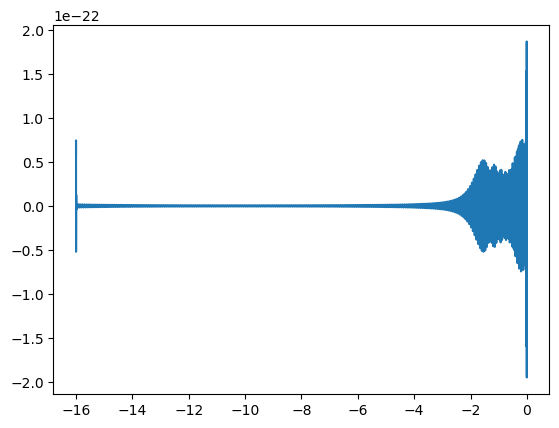

In [145]:
plt.plot(ht_pycbc.sample_times, ht_pycbc)
plt.show()
# plt.xlim(-16, -12)

In [146]:
keys = ['mass_1', 'mass_2', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'beta', 'distance', 'f_ref']
params = {}
for key in keys:
    params[key] = original_inj_params[key]
h_plus_harms = conversions.snr._calculate_precessing_harmonics(
    params["mass_1"][0],
    params["mass_2"][0],
    params["a_1"][0],
    params["a_2"][0],
    params["tilt_1"][0],
    params["tilt_2"][0],
    params["phi_12"][0],
    params["beta"][0],
    params["distance"][0],
    harmonics=[0, 1],
    approx='IMRPhenomPv2', mode_array=[[2, 2], [2, -2]],
    df=delta_f, f_low=f_low,
    f_ref=params["f_ref"][0]
)
h_perp_harms, _, _ = waveform_modes.orthonormalize_modes(
    h_plus_harms,
    ifo_psd=psd['H1'],
    f_low=f_low,
    modes=list(h_plus_harms.keys()),
    ortho_list=[0]
)
snr_dict1, _ = waveform_modes.calculate_mode_snr(
    ht_pycbc, psd['H1'], h_perp_harms,
    -0.1, 0.1, f_low=f_low, modes=[0, 1], dominant_mode=0
)

In [147]:
np.angle(snr_dict1[0]), np.angle(snr_dict1[1])

(1.118548605781866, 0.6528258634337475)

In [139]:
np.abs(snr_dict1[0])/np.abs(snr_dict1[1])

4.355413059264624

In [124]:
snr_dict1

{0: (3.909800144005915+8.047666443462289j),
 1: (1.6318430734743252+1.2478262908637154j)}

In [133]:
z_0 = (1 + np.cos(original_inj_params['theta_jn'][0])**2)/2*fp_j - 1j*np.cos(original_inj_params['theta_jn'][0])*fc_j
print(z_0)
z_1 = 2*np.exp(-1j*original_inj_params['phi_jl'][0])*(np.sin(original_inj_params['theta_jn'][0])*np.cos(original_inj_params['theta_jn'][0])*fp_j - 1j*np.sin(original_inj_params['theta_jn'][0])*fc_j)
print(z_1)
print(np.angle(z_0), np.angle(z_1))
print(np.abs(z_0)/np.abs(z_1))

(0.004996822710175908+0.5005420264174244j)
(0.8061145752894332+1.1461208717777729j)
1.5608138348814788 0.9578311457091663
0.3572368665254535


$$
z_0 = \frac{1+\cos{\theta_{JN}}^2}{2} f_{+j} - i \cos{\theta_{JN}} f_{\times J}
$$

$$
z_1 = 2e^{-i\phi_{JL}} \left(\sin{\theta_{JN}}\cos{\theta_{JN}} f_{+j} - i \sin{\theta_{JN}} f_{\times J} \right)
$$

This leads to

$$
A_0^2 = \left(\frac{1+\cos{\theta_{JN}}^2}{2} f_{+j}\right)^2 + \left(\cos{\theta_{JN}} f_{\times J}\right)^2
$$

$$
\tan{\varphi_0} = \frac{- 2\cos{\theta_{JN}} f_{\times J}}{1+\cos{\theta_{JN}}^2 f_{+j}}
$$

In [136]:
np.tan(original_inj_params['beta']/2)

Array([0.05309337])